In [1]:
import os
import textwrap
import json
import os, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pickle

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]

def list_subdirectories2(filtered_flux_dir):
    return [
        name.removeprefix('filtered_') for name in os.listdir(filtered_flux_dir)
        if os.path.isdir(os.path.join(filtered_flux_dir, name)) and 'logs' not in name
    ]


# Get the set of subdirectories present in both lists
def get_concurrent_subdirectories(flux_dir, filtered_flux_dir):
    subdirs1 = set(list_subdirectories(flux_dir))
    subdirs2 = set(list_subdirectories2(filtered_flux_dir))
    return list(subdirs1 & subdirs2)


In [2]:
flux_results_path = '/data3/jhpark/fusion_testing'
flux_results_dirs = list_subdirectories(flux_results_path)

In [3]:
flux_results_iter = iter(flux_results_dirs)

In [ ]:
def visualize(parent_dir, exp_dir, patch_size=16):
    
    exp_dir = os.path.join(parent_dir, exp_dir)
    if not os.path.isdir(exp_dir):
        raise FileNotFoundError(f"Experiment directory not found: {exp_dir}")
        
    def load_metadata(exp_dir):
        meta_path = os.path.join(exp_dir, "metadata.pkl")
        with open(meta_path, "rb") as f:
            metadata = pickle.load(f)
        # Normalize real_image_path
        rip = metadata.get("real_image_path")
        if rip and not os.path.isabs(rip):
            rip_candidate = os.path.join(exp_dir, rip)
            if os.path.exists(rip_candidate):
                metadata["real_image_path"] = rip_candidate
        return metadata
    
    # Limit
    
    type_colors = {
        'removal': 'red',
        'addition': 'green',
        'distortion': 'orange',
        'fusion': 'purple',
        'unknown': 'gray'
    }
    metadata = load_metadata(exp_dir)
    caption = metadata.get('caption', '(no caption)')
    artifacts = metadata.get('artifacts', []) or []
    
    # Original image
    real_img_path = metadata.get('real_image_path')
    orig_img = Image.open(real_img_path).convert("RGB")
    orig_img_array = np.array(orig_img)

    result_img = Image.open(os.path.join(exp_dir, 'artifact.png')).convert("RGB")
    
    H, W = orig_img_array.shape[:2]
    patch_H = H // patch_size
    patch_W = W // patch_size
    
    # Collect all reference & target patch indices
    all_ref_patch_indices = []
    all_target_patch_indices = []
    for art in artifacts:
        all_ref_patch_indices.extend(art.get('reference_patch_indices', []) or [])
        all_target_patch_indices.extend(art.get('target_patch_indices', []) or [])
    
    # De-duplicate preserving order
    def dedupe(seq):
        seen = set()
        out_ = []
        for x in seq:
            if x not in seen:
                seen.add(x)
                out_.append(x)
        return out_
    
    all_ref_patch_indices = dedupe(all_ref_patch_indices)
    all_target_patch_indices = dedupe(all_target_patch_indices)
    
    # Figure
    fig, axes = plt.subplots(1, 3, figsize=(36, 12))
    
    # Panel 1: Original
    axes[0].imshow(orig_img_array)
    axes[0].set_title("Original Image", fontsize=18, fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Patch assignments
    axes[1].imshow(orig_img_array)
    axes[1].set_title("Patch Assignments\nReference (Red) + Target (Blue)", fontsize=18, fontweight='bold')
    
    def draw_patch(idx, color):
        # Adjust index offset (subtract 512) if token shift applied
        idx_visual = idx - 512
        if 0 <= idx_visual < patch_H * patch_W:
            row = idx_visual // patch_W
            col = idx_visual % patch_W
            y_start = row * patch_size
            x_start = col * patch_size
            rect = patches.Rectangle(
                (x_start, y_start), patch_size, patch_size,
                linewidth=2, edgecolor=color, facecolor=color, alpha=0.4
            )
            axes[1].add_patch(rect)
    
    for idx in all_ref_patch_indices:
        draw_patch(idx, 'red')
    for idx in all_target_patch_indices:
        draw_patch(idx, 'blue')
    
    # Bounding boxes per artifact (target patches)
    for artifact in artifacts:
        artifact_type = artifact.get('artifact_type', 'unknown')
        target_indices = artifact.get('target_patch_indices', []) or []
        if not target_indices:
            continue
        
        min_x, max_x = float('inf'), -1
        min_y, max_y = float('inf'), -1
        
        for idx in target_indices:
            idx_visual = idx - 512
            if 0 <= idx_visual < patch_H * patch_W:
                row = idx_visual // patch_W
                col = idx_visual % patch_W
                y_start = row * patch_size
                x_start = col * patch_size
                min_x = min(min_x, x_start)
                max_x = max(max_x, x_start + patch_size)
                min_y = min(min_y, y_start)
                max_y = max(max_y, y_start + patch_size)
        
        if min_x == float('inf'):
            continue
        
        bbox_color = type_colors.get(artifact_type, 'gray')
        width = max_x - min_x
        height = max_y - min_y
        
        display_text = artifact_type
        if artifact_type == 'distortion' and 'distortion_kernel' in artifact:
            display_text = str(artifact['distortion_kernel'])
        
        bbox_rect = patches.Rectangle(
            (min_x, min_y), width, height,
            linewidth=3, edgecolor=bbox_color, facecolor='none', linestyle='--'
        )
        axes[1].add_patch(bbox_rect)
        axes[1].text(
            min_x, max(min_y - 5, 0), display_text,
            fontsize=18, fontweight='bold', color='black',
            ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                        edgecolor=bbox_color, alpha=0.9)
        )
    
    axes[1].axis('off')
    
    # Panel 3: Generated result
    axes[2].imshow(result_img)
    axes[2].set_title("Generated Result", fontsize=18, fontweight='bold')
    axes[2].axis('off')
    
    # Caption as super-title (wrapped)
    wrapped = "\n".join(
        [caption[i:i+140] for i in range(0, len(caption), 140)]
    )
    fig.suptitle(wrapped, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # type: ignore
    plt.show()
    plt.close(fig)


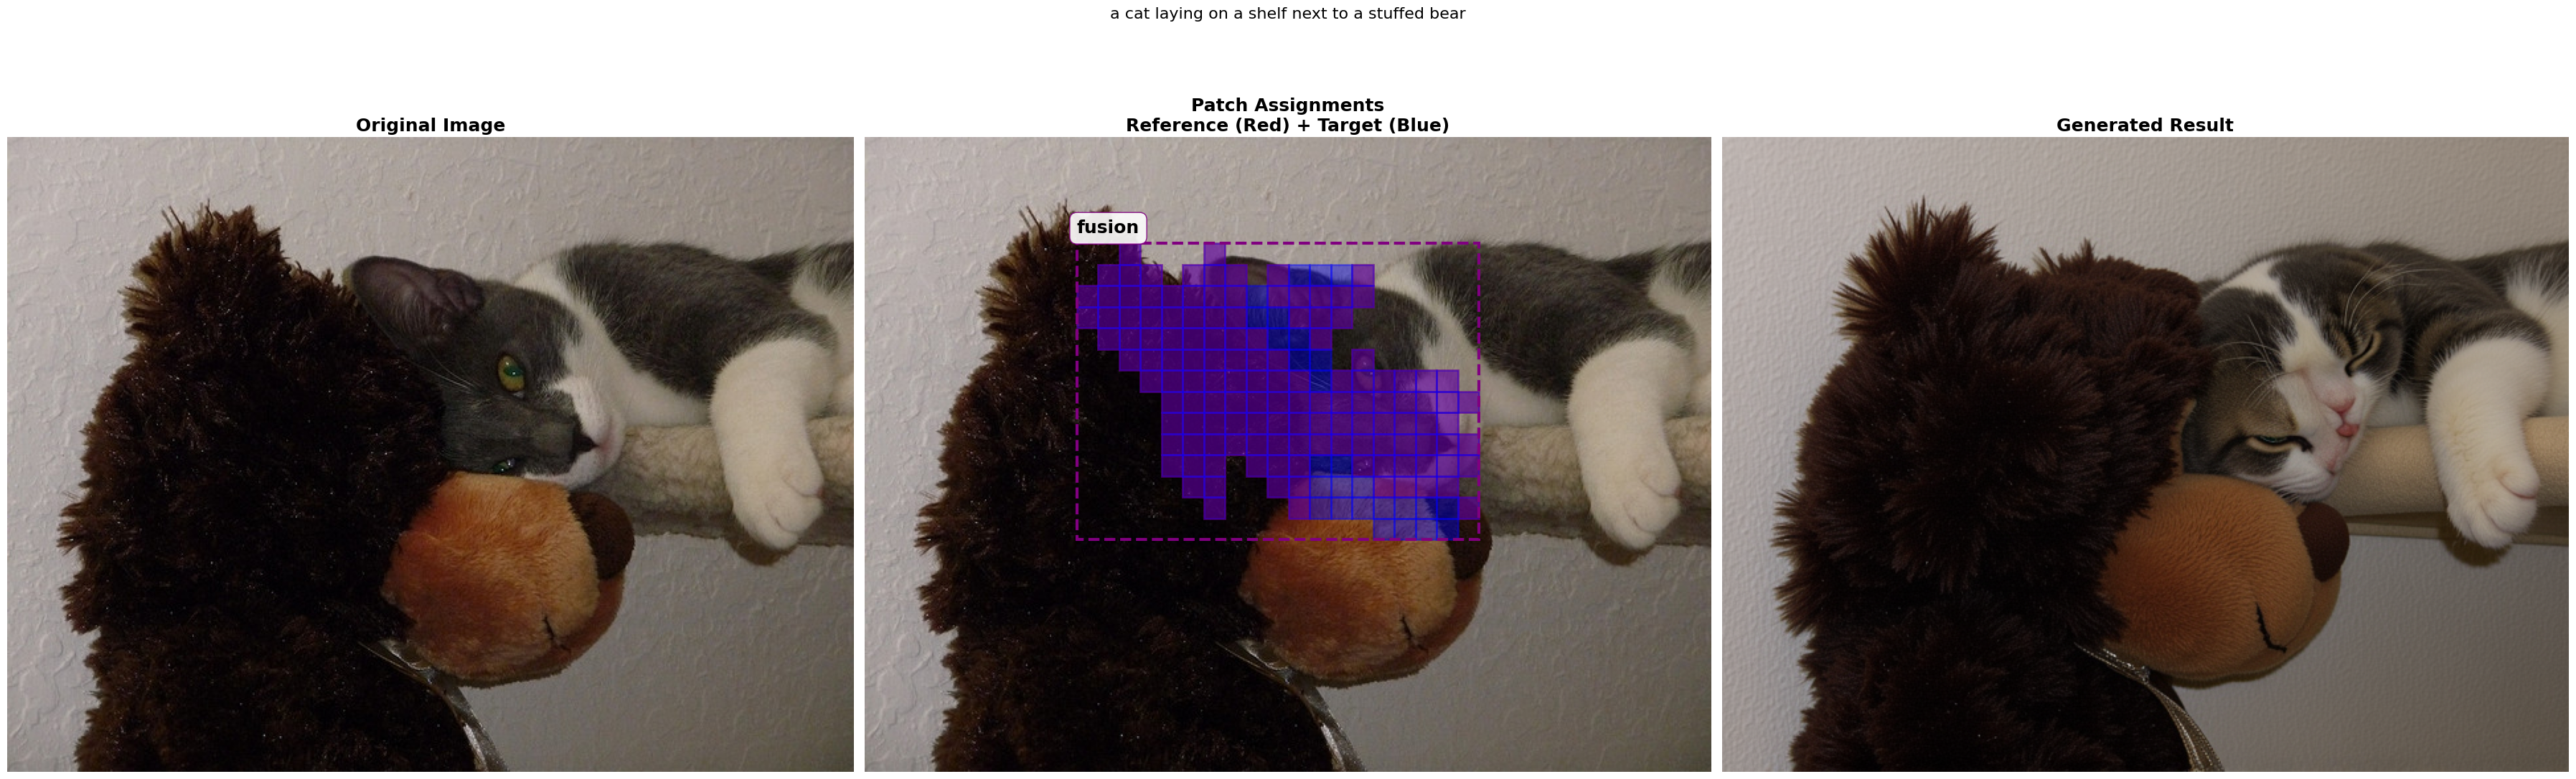

In [20]:
exp_dir = next(flux_results_iter)
visualize(flux_results_path, exp_dir)